In [1]:
import json
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import numericalunits as nu
import torch

REPO_ROOT = Path.cwd().parent if Path.cwd().name == 'tests' else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

from DMeRates.DMeRate import DMeRate

In [2]:
# mX = 10 *1e-3 #10 keV
# sigmaE = 1e-35
# halo_model = 'srdm'
# FDMn = 2
# ne = [1]


spec = dict(
        label='10 keV',
        mX_eV=1.0e4,
        sigma_e_cm2=1.0e-35,
        filename='srdm_dphidv_DPLM_fig22_mchi_10keV_sigmae_1e-35.txt',
        generated_path='fig22_DPLM_mchi_10keV_sigmae_1e-35_avg/Differential_SRDM_Flux.txt',
        config='config_fig22_DPLM_mchi_10keV_sigmae_1e-35.cfg',
    )

DoScreen = False
def run_public_drdE_curve(*, backend, spec, do_screen,screening):
    dm = DMeRate('Si', form_factor_type=backend)
    rates, dRdE, prob = dm.calculate_rates(
        mX_array=[spec['mX_eV'] / 1.0e6],
        halo_model='srdm',
        FDMn=2,
        ne=[1],
        DoScreen=do_screen,
        screening=screening,
        sigma_e=spec['sigma_e_cm2'],
        mediator_spin='vector',
        debug=True,
        integrate=True,
    )
    E_eV = (dm.Earr / nu.eV).detach().cpu().numpy()
    y = (dRdE * nu.kg * nu.year * nu.eV).detach().cpu().numpy()
    return E_eV, y


Drde_qedark = run_public_drdE_curve(backend='qedark',spec=spec,do_screen=False,screening=None)
Drde_qcdark = run_public_drdE_curve(backend='qcdark',spec=spec,do_screen=False,screening=None)
Drde_qcdark2 = run_public_drdE_curve(backend='qcdark2',spec=spec,do_screen=False,screening='none')

CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
Using form factor calculated from file: /Users/ansh/Local/SENSEI/DarkMatterRates/form_factors/QCDark/Si_final.hdf5
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)


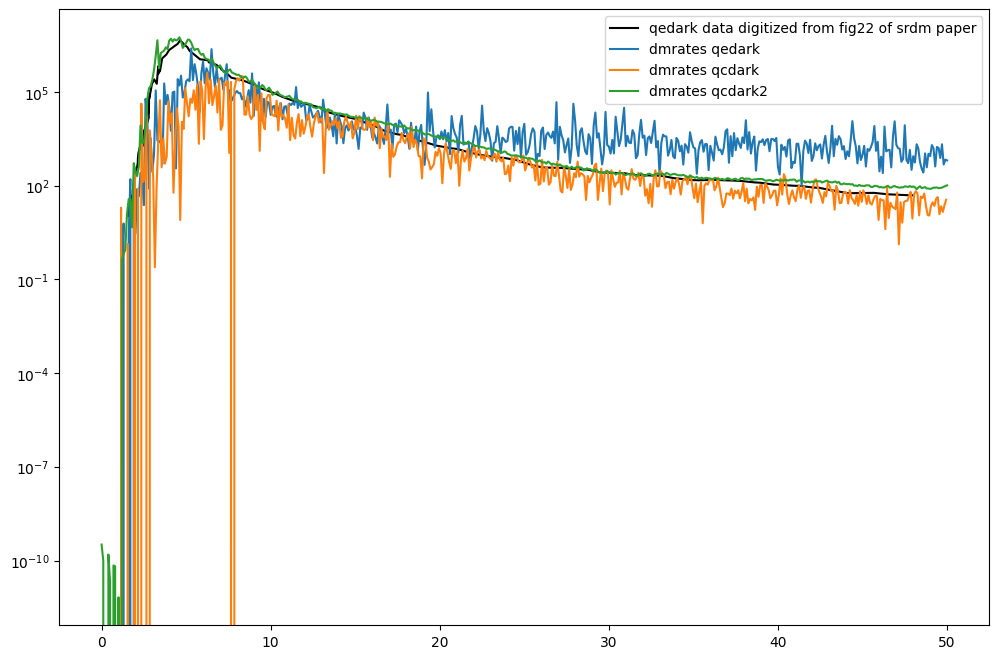

In [3]:
qedark_validation_data = np.loadtxt('../../fig22_validation/qedark_no_screening_10keV_1e-35_fig22.csv',delimiter=',')
plt.figure(figsize=(12,8))
plt.plot(qedark_validation_data[:,0],qedark_validation_data[:,1],color='black',label='qedark data digitized from fig22 of srdm paper')

plt.plot(Drde_qedark[0],Drde_qedark[1],label='dmrates qedark')
plt.plot(Drde_qcdark[0],Drde_qcdark[1],label='dmrates qcdark')
plt.plot(Drde_qcdark2[0],Drde_qcdark2[1],label='dmrates qcdark2')


plt.legend()
plt.yscale('log')
plt.show()
plt.close()

In [4]:
Drde_qedark = run_public_drdE_curve(backend='qedark',spec=spec,do_screen=True,screening='lindhard')
Drde_qcdark = run_public_drdE_curve(backend='qcdark',spec=spec,do_screen=True,screening='lindhard')
Drde_qcdark2 = run_public_drdE_curve(backend='qcdark2',spec=spec,do_screen=True,screening='rpa')

CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)
Using form factor calculated from file: /Users/ansh/Local/SENSEI/DarkMatterRates/form_factors/QCDark/Si_final.hdf5
CUDA/MPS GPU not found, performing calculations on cpu (if you are doing this on apple silicon you can change your device to mps if you'd like)


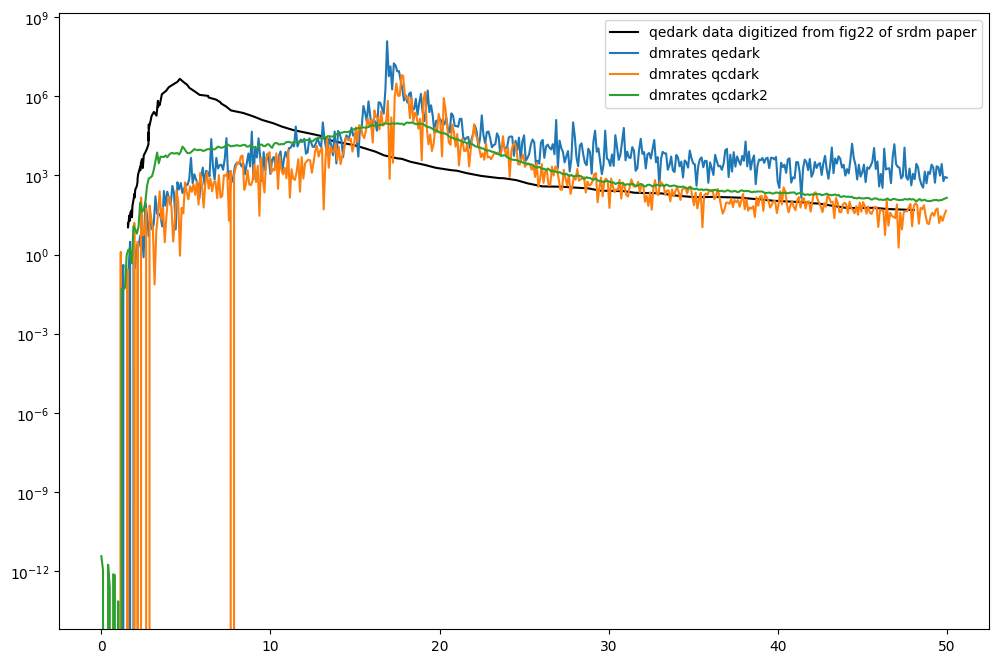

In [5]:
qedark_validation_data = np.loadtxt('../../fig22_validation/qedark_no_screening_10keV_1e-35_fig22.csv',delimiter=',')
plt.figure(figsize=(12,8))
plt.plot(qedark_validation_data[:,0],qedark_validation_data[:,1],color='black',label='qedark data digitized from fig22 of srdm paper')

plt.plot(Drde_qedark[0],Drde_qedark[1],label='dmrates qedark')
plt.plot(Drde_qcdark[0],Drde_qcdark[1],label='dmrates qcdark')
plt.plot(Drde_qcdark2[0],Drde_qcdark2[1],label='dmrates qcdark2')


plt.legend()
plt.yscale('log')
plt.show()
plt.close()